Use this notebook to check for consistency between MeVPrtl generator and the offline one that I wrote.
Note that MeVPrtl will generate all the possible events allowed for a given scalar mass (eg, above two-pion threshold, that includes all the final states (very few electrons)). The textGen generator only returns electrons if scalar mass is below two-muon limit, otherwise only muons. So to compare, make sure that you are considering just the final state of interest from MeVPrtl.

In [1]:
1+1

2

In [2]:
import uproot
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import h5py
import math

from scipy.stats import ks_2samp
from scipy.stats import epps_singleton_2samp

from util import *

import var
import cut
import data
import hist

import importlib

from pyanalib import panda_helpers
from unc_funcs import *

In [3]:
GOAL_POT = 6e20 
POTSTR = "6e20 POT"

## MeVPrtl Events

In [4]:
f = h5py.File('/exp/icarus/data/users/jdyer/dimuon-data/2402_hps_for_val/mS340mev_1e-5mix.df', 'r')
print(f.keys())

<KeysViewHDF5 ['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']>


In [5]:
print('MEVPRTL')

mevprtl_color = "#87CEEB"

# These are what I used prior to mishap of things getting deleted over weekend of 2/3:
#higgs_files = [
#    "/icarus/data/users/gputnam/dimuon-data/higgs-gen-A/higgs_M240_DMCP2023G_evt_new.df",
#    "/icarus/data/users/gputnam/dimuon-data/higgs-gen-A/higgs_M330_DMCP2023G_evt_new.df"
#]

# these exclude KDAR:
higgs_files = [
    "/icarus/data/users/gputnam/DMCP2023G/mc-F/F2-Higgs_M240_nom_evt.df",
    "/icarus/data/users/gputnam/DMCP2023G/mc-F/F2-Higgs_M340_nom_evt.df",
    "/icarus/data/users/gputnam/DMCP2023G/mc-F/F2-Higgs_M240_nom_evt.df" # placeholder for 100 MeV for now.
]

# Regenerated by me 2/7/24:
# these have all the kaons, made with microBoone flux files:
# /cvmfs/sbn.osgstorage.org/pnfs/fnal.gov/usr/sbn/persistent/stash/physics-gputnam/numiflux/
# NOTE: These include muon AND pion AND some electrons (should be negligible above dimuon mass for scalar) in final states!
higgs_files = [
    "/exp/icarus/data/users/jdyer/dimuon-data/2402_hps_for_val/mS240mev1e-5mix.df",
    "/exp/icarus/data/users/jdyer/dimuon-data/2402_hps_for_val/mS340mev_1e-5mix.df",
    "/exp/icarus/data/users/jdyer/dimuon-data/2402_hps_for_val/mS100mev2e-4mix.df" 
]


f = h5py.File(higgs_files[0], 'r')
print(f.keys())

higgs_mcdfs = [pd.read_hdf(f, key="mch") for f in higgs_files]
higgs_masses = [int(round(df.iloc[(0)].M*1000.)) for df in higgs_mcdfs]
higgs_thetas = [float(df.iloc[(0)].C1) for df in higgs_mcdfs]
higgs_mass_labels = []
higgs_th_labels = []
higgs_labels = []
for i in range(len(higgs_files)):
    higgs_mass_labels.append("$M_S$ = %a" % higgs_masses[i])
    higgs_th_labels.append("$\\theta_S$ = %a" % higgs_thetas[i])
    higgs_labels.append(higgs_mass_labels[i] + ", " + higgs_th_labels[i])

evtdfs = [pd.read_hdf(f, key="evt") for f in higgs_files]
#evtdfs = [data.mc_dataset(f, "evt").df for f in higgs_files]
hdrs = [pd.read_hdf(f, key="hdr") for f in higgs_files]
pots = [np.sum(hdr.pot * hdr.first_in_subrun) for hdr in hdrs]
#new_pots = [data.mc_dataset(f, "evt").POT for f in higgs_files]
new_pots = [np.sum(hdr.pot) for hdr in hdrs]
for i in range(3):
    print(higgs_labels[i])
    print("pot I used previously: ", pots[i])
    print("pot extracted the new way: ", new_pots[i])
    print('\n')
mcnus = [pd.read_hdf(f, key="mcnu") for f in higgs_files]
scales = [GOAL_POT / pot for pot in pots]

# NOTE: mcdf doesn't care how it was reconstructed; evtdf relied on being reconstructed already.

final_state_masks = []
E = []
for i,f in enumerate(higgs_files):
    if ((i == 0) | (i == 1)): 
        final_state_mask = mcnus[i].nmu == 2
    if i == 2:
        final_state_mask = ((mcnus[i].nmu == 0) & (mcnus[i].npi == 0) & (mcnus[i].npi0 == 0)) # then ee (there's no ne in the dataframe)
    final_state_masks.append(final_state_mask)
    E.append(np.array(higgs_mcdfs[i][final_state_mask].E))
    
n_mcevents = [x.shape[0] for x in E]
n_expevents = np.array(n_mcevents)*np.array(scales)

for i in range(len(higgs_mcdfs)):
    print(higgs_labels[i])
    print('Number of unweighted events (just muons (or ee for 100MeV) in final state): ', n_mcevents[i])
    print('POT needed for this many (unweighted) events to happen in ICARUS: ', pots[i]) # number of POT needed to get that many events (at whatever model benchmarks)
    # we need to calculate quivalent thing for textgen sample, and use that to POT-normalize.
    print('Number of expected events per %a POT: ' % GOAL_POT, n_expevents[i])
    print('\n')


MEVPRTL
<KeysViewHDF5 ['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']>
$M_S$ = 240, $\theta_S$ = 1e-05
pot I used previously:  4.4085482e+24
pot extracted the new way:  4.4085482e+24


$M_S$ = 340, $\theta_S$ = 1e-05
pot I used previously:  6.640615e+23
pot extracted the new way:  6.640615e+23


$M_S$ = 100, $\theta_S$ = 0.0002
pot I used previously:  6.711329e+23
pot extracted the new way:  6.711329e+23


$M_S$ = 240, $\theta_S$ = 1e-05
Number of unweighted events (just muons (or ee for 100MeV) in final state):  23468
POT needed for this many (unweighted) events to happen in ICARUS:  4.4085482e+24
Number of expected events per 6e+20 POT:  3.1939766714804865


$M_S$ = 340, $\theta_S$ = 1e-05
Number of unweighted events (just muons (or ee for 100MeV) in final state):  5585
POT needed for this many (unweighted) events to happen in ICARUS:  6.640615e+23
Number of expected events per 6e+20 POT:  5.046219138306428


$M_S$ = 100, $\theta_S$ = 0.0002
Number of unweighted events (just muons (or ee fo

## textGen

In [6]:
# copy of cell below to run July 3, 2025 (probably won't work)

print('TEXTGEN')

textGen_color = "C3"

textGen_E = []

textGen_n_mcevents = []
textGen_n_expevents = []
textGen_scales = []

textGen_files = [
    "textGen_validation/S_energies_240mev1e-5mix.txt",
    "textGen_validation/S_energies_340mev1e-5mix.txt", 
    "textGen_validation/S_energies_100mev2e-4mix.txt"
]

textGen_hdr_files = [
    "textGen_validation/hdr_240mev1e-5mix.txt",
    "textGen_validation/hdr_340mev1e-5mix.txt", 
    "textGen_validation/hdr_100mev2e-4mix.txt"
]

textGen_higgs_labels = []
textGen_labels_abbrev = []

for i in range(len(textGen_hdr_files)):
    filename = textGen_files[i]
    model_str = filename.split('/')[-1].split('_')[2]
    textGen_labels_abbrev.append(model_str.split('.')[0])
    print(model_str)
    label = "$M_S$ = %a, $\\theta_S$ = %a" % (int(model_str.split('mev')[0]), 
                                              float(model_str.split('mev')[1].split('mix')[0]))
    textGen_higgs_labels.append(label)
    tgw = [] # 'tg' for textGen
    tgE = []
    with open(textGen_files[i], 'r') as f:
        for rawline in f:
            line = rawline.split()
            tgw += [float(line[0])]
            tgE +=[float(line[3])]
    textGen_E.append(np.array(tgE))

    h = []
    with open(textGen_hdr_files[i], 'r') as f:
        for rawline in f:
            h.append(rawline.split('_')[0])
    #print(h)
    tgnfiles = (int(h[0]))
    tgnevents_gen_tot = (int(h[1]))
    tgmax_weight = (float(h[2])/(6e20/500000.))
    tgnevents_keep = (int(h[3]))

    textGen_gen_pot = 500000.*tgnfiles # number of POT used to generate the sample.
    textGen_scale = (tgmax_weight*GOAL_POT/textGen_gen_pot)#*(max_weight)
    
    textGen_scales.append(textGen_scale)

    tgn_mcevents = tgnevents_keep # Number of unweighted events in ICARUS
    tgn_expevents = tgn_mcevents*textGen_scale
    
    textGen_n_mcevents.append(tgn_mcevents)
    textGen_n_expevents.append(tgn_expevents)

    print(label)
    print("Number of flux file used for generation: ", tgnfiles)
    print("Number of total (weighted) events generated: ", tgnevents_gen_tot)
    print("Number of POT used to generate these events: ", textGen_gen_pot)
    print('Max weight: ', tgmax_weight)
    print('Number of events kept after unweighting: ', tgn_mcevents)
    print("Number of events occuring in ICARUS this corresponds to, for textGen_gen_pot POT: ", tgn_mcevents)
    print('Number of expected events per %a POT: ' % GOAL_POT, tgn_expevents)
    # Isn't this^ number as variable as the max_weight you happen to get? How bad is it if it doesn't agree?
    print('\n')
    


TEXTGEN
240mev1e-5mix.txt


FileNotFoundError: [Errno 2] No such file or directory: 'textGen_validation/S_energies_240mev1e-5mix.txt'

In [37]:
print('TEXTGEN')

textGen_color = "C3"

textGen_E = []

textGen_n_mcevents = []
textGen_n_expevents = []
textGen_scales = []

textGen_files = [
    "textGen_validation/S_energies_240mev1e-5mix.txt",
    "textGen_validation/S_energies_340mev1e-5mix.txt", 
    "textGen_validation/S_energies_100mev2e-4mix.txt"
]

textGen_hdr_files = [
    "textGen_validation/hdr_240mev1e-5mix.txt",
    "textGen_validation/hdr_340mev1e-5mix.txt", 
    "textGen_validation/hdr_100mev2e-4mix.txt"
]

textGen_higgs_labels = []
textGen_labels_abbrev = []

for i in range(len(textGen_hdr_files)):
    filename = textGen_files[i]
    model_str = filename.split('/')[-1].split('_')[2]
    textGen_labels_abbrev.append(model_str.split('.')[0])
    print(model_str)
    label = "$M_S$ = %a, $\\theta_S$ = %a" % (int(model_str.split('mev')[0]), 
                                              float(model_str.split('mev')[1].split('mix')[0]))
    textGen_higgs_labels.append(label)
    tgw = [] # 'tg' for textGen
    tgE = []
    with open(textGen_files[i], 'r') as f:
        for rawline in f:
            line = rawline.split()
            tgw += [float(line[0])]
            tgE +=[float(line[3])]
    textGen_E.append(np.array(tgE))

    h = []
    with open(textGen_hdr_files[i], 'r') as f:
        for rawline in f:
            h.append(rawline.split('_')[0])
    #print(h)
    tgnfiles = (int(h[0]))
    tgnevents_gen_tot = (int(h[1]))
    tgmax_weight = (float(h[2])/(6e20/500000.))
    tgnevents_keep = (int(h[3]))

    textGen_gen_pot = 500000.*tgnfiles # number of POT used to generate the sample.
    textGen_scale = (tgmax_weight*GOAL_POT/textGen_gen_pot)#*(max_weight)
    
    textGen_scales.append(textGen_scale)

    tgn_mcevents = tgnevents_keep # Number of unweighted events in ICARUS
    tgn_expevents = tgn_mcevents*textGen_scale
    
    textGen_n_mcevents.append(tgn_mcevents)
    textGen_n_expevents.append(tgn_expevents)

    print(label)
    print("Number of flux file used for generation: ", tgnfiles)
    print("Number of total (weighted) events generated: ", tgnevents_gen_tot)
    print("Number of POT used to generate these events: ", textGen_gen_pot)
    print('Max weight: ', tgmax_weight)
    print('Number of events kept after unweighting: ', tgn_mcevents)
    print("Number of events occuring in ICARUS this corresponds to, for textGen_gen_pot POT: ", tgn_mcevents)
    print('Number of expected events per %a POT: ' % GOAL_POT, tgn_expevents)
    # Isn't this^ number as variable as the max_weight you happen to get? How bad is it if it doesn't agree?
    print('\n')
    

TEXTGEN
240mev1e-5mix.txt
$M_S$ = 240, $\theta_S$ = 1e-05
Number of flux file used for generation:  10020
Number of total (weighted) events generated:  80725944
Number of POT used to generate these events:  5010000000.0
Max weight:  6.197841027273102e-15
Number of events kept after unweighting:  4304
Number of events occuring in ICARUS this corresponds to, for textGen_gen_pot POT:  4304
Number of expected events per 6e+20 POT:  3.194671590584842


340mev1e-5mix.txt
$M_S$ = 340, $\theta_S$ = 1e-05
Number of flux file used for generation:  15030
Number of total (weighted) events generated:  63455907
Number of POT used to generate these events:  7515000000.0
Max weight:  4.088284223962787e-14
Number of events kept after unweighting:  1629
Number of events occuring in ICARUS this corresponds to, for textGen_gen_pot POT:  1629
Number of expected events per 6e+20 POT:  5.31721756553723


100mev2e-4mix.txt
$M_S$ = 100, $\theta_S$ = 0.0002
Number of flux file used for generation:  501
Number o

## Compare

In [64]:
# Choose which mass point to generate plots for here:
m = 1
mybins = 20

Verify that I am comparing the same model benchmarks:
MeVPrtl benchmark:  $M_S$ = 340, $\theta_S$ = 1e-05
textGen benchmark:  $M_S$ = 340, $\theta_S$ = 1e-05


Total # of MC events from MeVPrtl:  5585
Total # of MC events from textGen:  1629
Range in energy being plotted:  (0, 4)
0    11.621436
dtype: float64
0    7.967786
dtype: float64
Total # of MC events from MeVPrtl IN RANGE:  5406
Total # of MC events from textGen IN RANGE:  1590


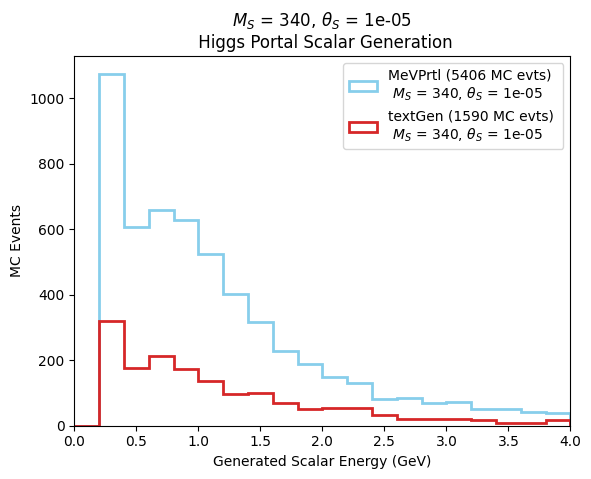

In [65]:
# Density = False

xrange = (0,4)
#xrange = (0.4, 4) # excludes KDAR

print('Verify that I am comparing the same model benchmarks:')
print('MeVPrtl benchmark: ', higgs_labels[m])
print('textGen benchmark: ', textGen_higgs_labels[m])
print('\n')

print("Total # of MC events from MeVPrtl: ", E[m].shape[0])
print("Total # of MC events from textGen: ", textGen_E[m].shape[0])

print("Range in energy being plotted: ", xrange)

E_df = pd.DataFrame(E[m])
textGen_E_df = pd.DataFrame(textGen_E[m])
print(np.max(E_df))
print(np.max(textGen_E_df))

mc_inrange = E_df[((E_df[0]>=xrange[0]) & (E_df[0]<=xrange[1]))].shape[0]
textGen_mc_inrange = textGen_E_df[((textGen_E_df[0]>=xrange[0]) & (textGen_E_df[0]<=xrange[1]))].shape[0]

print("Total # of MC events from MeVPrtl IN RANGE: ", mc_inrange)
print("Total # of MC events from textGen IN RANGE: ", textGen_mc_inrange)


#print("Number of MeVPrtl events with energies outside this range: ", E_df[~((E_df[0]>=xrange[0]) & (E_df[0]<=xrange[1]))].shape[0])
#print("Number of textGen events with energies outside this range: ", textGen_E_df[~((textGen_E_df[0]>=xrange[0]) & (textGen_E_df[0]<=xrange[1]))].shape[0])
# 'df' for 'Density = False'
(dfna,binsa,patchesa) = plt.hist(E[m], bins=mybins, label = 'MeVPrtl (%s MC evts) \n %s' % (mc_inrange, higgs_labels[m]), 
                                 color=mevprtl_color, histtype="step", linewidth=2, density=False, range=xrange) # , weights=scale[c], categories[c].name.split(',')[0]
(dfnb,binsb,patchesb) = plt.hist(textGen_E[m], bins=mybins, label='textGen (%s MC evts) \n %s' % (textGen_mc_inrange, textGen_higgs_labels[m]),
                                 color=textGen_color, histtype="step", linewidth=2, density=False, range=xrange) # , weights=scale[c], categories[c].name.split(',')[0]
plt.xlim(xrange)
plt.xlabel("Generated Scalar Energy (GeV)") # Total energy, not just kinetic.
plt.ylabel("MC Events")
plt.title(higgs_labels[m]+'\n Higgs Portal Scalar Generation')
plt.legend()
plt.show()



In [66]:
print('Ratio of (MeVPrtl MC Stats)/(textGen MC Stats): %s' % (E[m].shape[0]/textGen_E[m].shape[0]) )

Ratio of (MeVPrtl MC Stats)/(textGen MC Stats): 3.4284837323511357


In [67]:
# Find factors used for area normaliztion.

density = True
#xrange = (0.2,1.2)
(na,binsa,patchesa) = plt.hist(E[m], bins=mybins, label='MeVPrtl \n %s' % higgs_labels[m], color=mevprtl_color,
                 histtype="step", linewidth=2, density=density, range=xrange) # , weights=scale[c], categories[c].name.split(',')[0]
(nb,binsb,patchesb) = plt.hist(textGen_E[m], bins=mybins, label='textGen \n %s' % textGen_higgs_labels[m], color=textGen_color,
                 histtype="step", linewidth=2, density=density, range=xrange) # , weights=scale[c], categories[c].name.split(',')[0]
plt.close()

# Find factors used for normalization:

print(na/dfna)
a_normalization = na[-2]/dfna[-2]
print(a_normalization)
a_poisson = np.sqrt(dfna) # Poisson error for non-normalized events.
print('')

print(nb/dfnb)
b_normalization = nb[-2]/dfnb[-2]
print(b_normalization)
b_poisson = np.sqrt(dfnb)

print('')

print(a_poisson)
print(a_normalization)
print(b_poisson)
print(b_normalization)


[      nan 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249
 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249
 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249 0.0009249]
0.0009248982611912681

[       nan 0.00314465 0.00314465 0.00314465 0.00314465 0.00314465
 0.00314465 0.00314465 0.00314465 0.00314465 0.00314465 0.00314465
 0.00314465 0.00314465 0.00314465 0.00314465 0.00314465 0.00314465
 0.00314465 0.00314465]
0.0031446540880503116

[ 0.         32.78719262 24.65765601 25.69046516 25.07987241 22.91287847
 20.02498439 17.8325545  15.09966887 13.78404875 12.16552506 11.40175425
  9.          9.21954446  8.36660027  8.48528137  7.21110255  7.21110255
  6.4807407   6.32455532]
0.0009248982611912681
[ 0.         17.91647287 13.22875656 14.59451952 13.19090596 11.74734012
  9.8488578  10.04987562  8.24621125  7.21110255  7.28010989  7.34846923
  5.74456265  4.47213595  4.69041576  4.58257569  4.12310563  2.82842712
  2.64575131  4.        ]
0.00314465408

/tmp/ipykernel_190786/1547754515.py:13: RuntimeWarning: invalid value encountered in true_divide
  print(na/dfna)
/tmp/ipykernel_190786/1547754515.py:19: RuntimeWarning: invalid value encountered in true_divide
  print(nb/dfnb)


23.705381937730973
chi2 over n = 1.1852690968865487


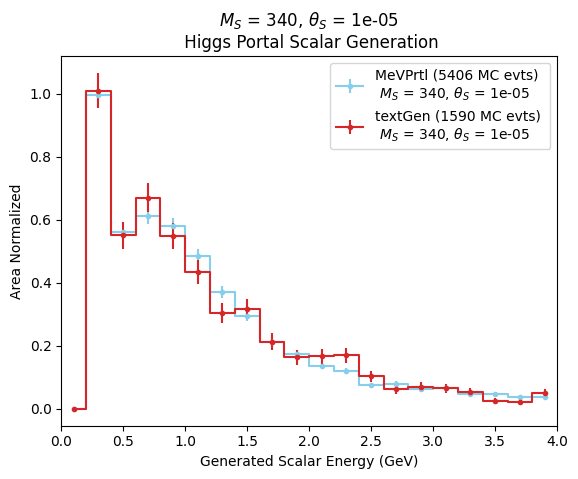

In [68]:
# Area Normalized, W/ Error bars

a_err = a_poisson*a_normalization # Error to use on area-normalized bins.
b_err = b_poisson*b_normalization

bin_centers = 0.5*(binsa[1:] + binsa[:-1])
plt.errorbar( bin_centers, na, marker = '.', drawstyle = 'steps-mid', yerr = a_err, 
             label = 'MeVPrtl (%s MC evts) \n %s' % (mc_inrange, higgs_labels[m]), color=mevprtl_color) #
plt.errorbar( bin_centers, nb, marker = '.',drawstyle = 'steps-mid', yerr = b_err, 
             label='textGen (%s MC evts) \n %s' % (textGen_mc_inrange, textGen_higgs_labels[m]), color=textGen_color) # 
plt.xlim(xrange)

arr = (a_normalization*na+b_normalization*nb)
okay_denom = arr!=0
#print(okay_denom)
chi2 = np.sum(((na-nb)[okay_denom]**2)/(a_normalization*na+b_normalization*nb)[okay_denom] ) #1/11/24
print(chi2)
ndof = len(bin_centers)
howgood = chi2/ndof
print('chi2 over n = %a' % howgood )
#plt.text(2., 0.8, "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)

#plt.yscale('log')
plt.ylabel("Area Normalized")
plt.xlabel("Generated Scalar Energy (GeV)") # Total energy, not just kinetic.
plt.title(higgs_labels[m]+'\n Higgs Portal Scalar Generation')
plt.legend()

plt.show()

chi2 over n = 1.3977537264529791


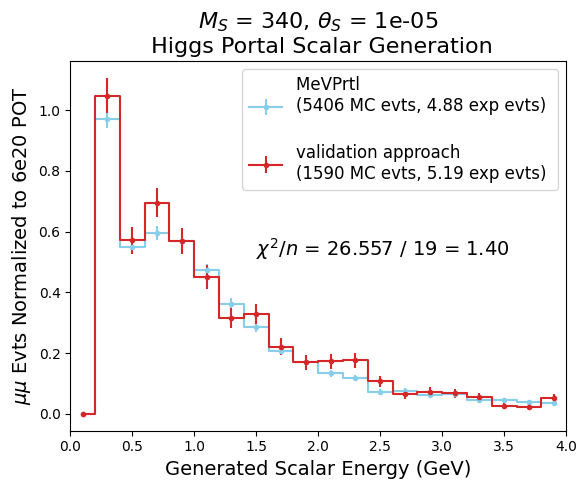

In [69]:
# POT Normalized, W/ error bars

# W/ Error bars

fs = 14

a_err = a_poisson*scales[m]
b_err = b_poisson*textGen_scales[m]

exp_inrange = np.sum(dfna*scales[m])
textGen_exp_inrange = np.sum(dfnb*textGen_scales[m])

bin_centers = 0.5*(binsa[1:] + binsa[:-1])
plt.errorbar( bin_centers, dfna*scales[m], marker = '.', drawstyle = 'steps-mid', yerr = a_err, 
             label = 'MeVPrtl \n(%s MC evts, %.2f exp evts) \n' % 
             (mc_inrange, exp_inrange),
             #label = 'MeVPrtl \n %s \n(%s MC evts, %.2f exp evts) \n' % 
             #(higgs_labels[m], mc_inrange, exp_inrange), 
             color=mevprtl_color) # , yerr = a_poisson*scale
plt.errorbar( bin_centers, dfnb*textGen_scales[m], marker = '.',drawstyle = 'steps-mid', yerr = b_err,
             label='validation approach \n(%s MC evts, %.2f exp evts)' % 
             (textGen_mc_inrange,textGen_exp_inrange),
             #label='validation approach \n %s \n(%s MC evts, %.2f exp evts)' % 
             #(textGen_higgs_labels[m], textGen_mc_inrange,textGen_exp_inrange),
             color=textGen_color) #, yerr = G_err # label='textGen \n(%s MC evts, %s exp evts)' % (textGen_n_mcevents,round(textGen_n_expevents))
plt.xlim(xrange)

arr = (scales[m]*scales[m]*dfna + textGen_scales[m]*textGen_scales[m]*nb)
okay_denom = arr!=0
ndof = dfna[okay_denom].shape[0]
chi2 = np.sum( ((scales[m]*dfna-textGen_scales[m]*dfnb)[okay_denom]**2)/(scales[m]*scales[m]*dfna + textGen_scales[m]*textGen_scales[m]*dfnb)[okay_denom] ) #1/11/24
howgood = chi2/ndof
print('chi2 over n = %a' % howgood )
if m==0:
    ## including kdar:
    plt.text(1.25, 0.55, "$\\chi^2/n$ = %.3f / %i = %.2f" % (chi2, ndof, howgood), fontsize=fs)
    # excluding kdar:
    #plt.text(2., 0.15, "$\\chi^2/n$ = %.3f / %i = %.2f" % (chi2, ndof, howgood), fontsize=fs)
    fs_label = '$\\mu\\mu$ Evts '
if m==1:
    # including kdar bin:
    plt.text(1.5, 0.52, "$\\chi^2/n$ = %.3f / %i = %.2f" % (chi2, ndof, howgood), fontsize=fs)
    ## excluding kdar bin:
    #plt.text(2, 0.28, "$\\chi^2/n$ = %.3f / %i = %.2f" % (chi2, ndof, howgood), fontsize=fs)#, transform=plt.transAxes)
    fs_label = '$\\mu\\mu$ Evts '
if m==2:
    plt.text(1.5, 3, "$\\chi^2/n$ = %.3f / %i = %.2f" % (chi2, ndof, howgood), fontsize=fs)
    fs_label = '$ee$ Evts '
#plt.yscale('log')
plt.ylabel(fs_label + "Normalized to %s" % POTSTR, fontsize=fs)
plt.xlabel("Generated Scalar Energy (GeV)", fontsize=fs) # Total energy, not just kinetic.
plt.title(higgs_labels[m]+'\n Higgs Portal Scalar Generation', fontsize=fs+2)
plt.legend(fontsize=fs-2)

plt.savefig('textGen_validation/higgs_val_%s.png' % textGen_labels_abbrev[m], format='png', bbox_inches='tight', pad_inches=0.25)
plt.show()

In [31]:
# Compare expected event rates:

print(1268-np.sqrt(1268), 1268+np.sqrt(1268), sep=', ')
print(1262-np.sqrt(1262), 1262+np.sqrt(1262), sep=', ')


1232.3910123704702, 1303.6089876295298
1226.4753606633367, 1297.5246393366633


In [15]:
# Ratio of detector volumes used in oldGeom of textGen vs. newGeom:

V = (368.49+368.49)*(191.86+144.96)*(904.950652270838+904.950652270838)
textGen_V = (1.7341+1.4341)*(2*3.6449)*(9.09951+8.79951)*100*100*100.
print('V/textGen_V = %s' % (V/textGen_V))
print('exp events / textGen exp events = %s' % (n_expevents/textGen_n_expevents))


V/textGen_V = 1.0868034553220907
exp events / textGen exp events = 1.004817151772656


## July 7, 2025: I need to redo the titles of the plots for the publication draft version of the TN
Unfortunately, I've lost some files needed to easily remake the plots, but I can just make bologna plots with the corrected titles and do some offline fanagling to overlay them on the images of the plots I have.

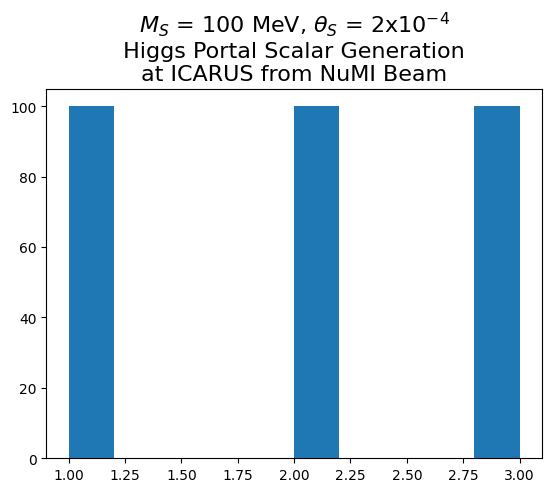

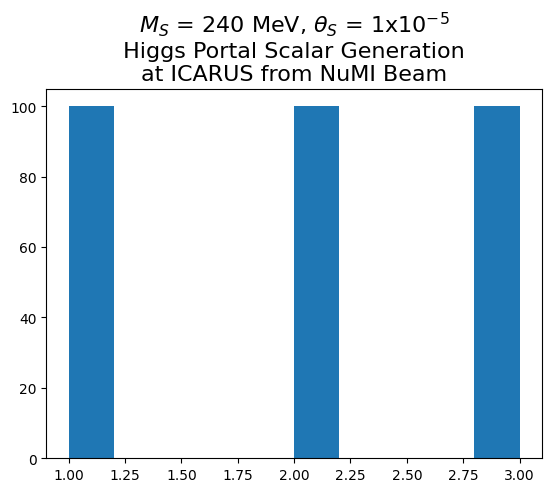

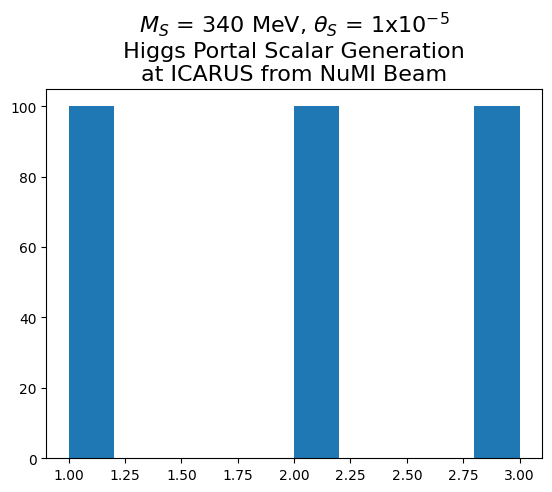

In [15]:
# POT Normalized, W/ error bars

higgs_labels = [
    r'$M_S$ = 100 MeV, $\theta_S$ = 2x$10^{-4}$',
    r"$M_S$ = 240 MeV, $\theta_S$ = 1x$10^{-5}$",
    r"$M_S$ = 340 MeV, $\theta_S$ = 1x$10^{-5}$"    
]

# W/ Error bars
for n, l in enumerate(higgs_labels):
    fs=14
    plt.hist([1,2,3]*100)
    plt.title(l+'\n Higgs Portal Scalar Generation \nat ICARUS from NuMI Beam', fontsize=fs+2)
    plt.savefig('textGen_Validation_plot_Titles_%a.png' % n, format='png', bbox_inches='tight', pad_inches=0.25)
    plt.show()